The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


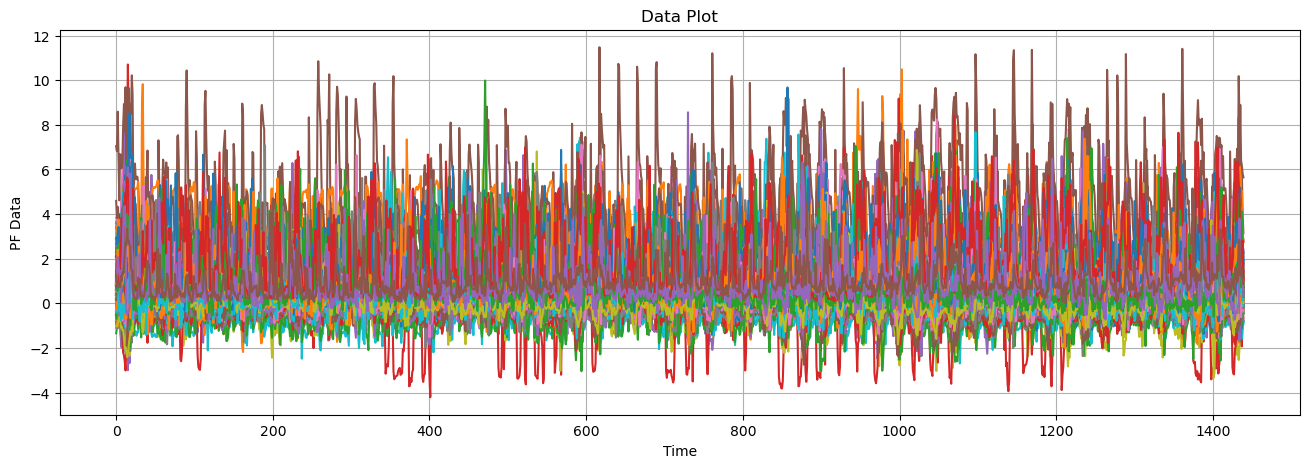

In [198]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
import lib.subBase as subBase
import lib.utils as utils
import lib.ac_se_fdia as ac_se_fdia
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from lib.read_ac_pf_csv import read_ac_power_flow_data
from scipy.linalg import qr
import pandapower as pp
import pandapower.networks as nw
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import scipy.io
import json


def roc_pr_auc(groundTruth, residual):
    roc_auc = roc_auc_score(groundTruth, residual)
    precisionT, recallT, thresholds = precision_recall_curve(groundTruth, residual)
    pr_auc = auc(recallT, precisionT)
    return roc_auc, pr_auc, precisionT, recallT


powerID= 118
attacktypes= ["pca", "svd", "iattackgen", "ours"]
attacktype= attacktypes[3]
case_map = {14: nw.case14, 30: nw.case30, 57: nw.case57, 118: nw.case118}
net = case_map[powerID]()

AC_file= f'C:/Users/30678/Desktop/large_files/1_3_ac_power_chenhan_2026/results{powerID}_AC.xlsx'
AC_file_new= f'C:/Users/30678/Desktop/large_files/1_3_ac_power_chenhan_2026/new_data/results{powerID}_{attacktype}_AC.xlsx'
AC_Chen_results_new= f'C:/Users/30678/Desktop/large_files/1_3_ac_power_chenhan_2026/new_detect/baseline{powerID}.json'
matpower_file= f'matpower/test_data/AC_case{powerID}_.mat' #14, 118, 57, 30
LSTMFile= f"C:/Users/30678/Desktop/large_files/1_3_ac_power_chenhan_2026/LSTM_detect/IEEE{powerID}.mat"
LSTMFile_new= f'C:/Users/30678/Desktop/large_files/1_3_ac_power_chenhan_2026/new_detect/deepsignalanomalydetectorIEEE{powerID}_w60_1250_results{powerID}_{attacktype}_AC.mat'
_, _, H, A, _, resistance, voltage, reactance= ioFile.read_mat_power(matpower_file, normalize= False)
m= H.shape[0]
n= H.shape[1]
rankH= n-1
nullity= m- rankH
stdOfNoise= 1e-3
numTrain= m*2
thresholdCut= 0.09
pfDataAc, _=ioFile.read_excel_power(AC_file_new, id1= 0, id2= 0)
with open(AC_Chen_results_new, 'r', encoding='utf-8') as file:
    AC_Chen_results_new_data = json.load(file)
trainPf= pfDataAc[:numTrain, :]
testPf= pfDataAc[:, :]
groundTruth= np.zeros(pfDataAc.shape[0])
groundTruth[1200:1300]= 1
groundTruthTest= groundTruth[:]
# testPf= testPf-np.mean(testPf, 0, keepdims= True)
plotTimeSeries= True
if plotTimeSeries:
    plt.figure(figsize=(16, 5))
    for i in range(m):
        plt.plot((pfDataAc)[:, i], label=i)
    # plt.yscale("log")
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.show()


In [199]:
U, S, V= np.linalg.svd(trainPf.T@trainPf)
nullitySet= np.sum(S<thresholdCut)
nullSpace= V[-nullitySet:, :]
detect2= nullSpace@testPf.T
U, S, V= np.linalg.svd(H@H.T)
nullSpaceH= V[-nullity:, :]
detect1= nullSpaceH@testPf.T
detectIF= np.array(AC_Chen_results_new_data[attacktype])
normDetect1= np.linalg.norm(detect1.T, axis= 1)
normDetect2= np.linalg.norm(detect2.T, axis= 1)

G, node_pair2id = graph.from_A_to_G(A)
minimum_cycle_b= nx.minimum_cycle_basis(G, weight="weight")
minimum_cycle_b= [list(i) for i in minimum_cycle_b]
minimum_cycle_e= []
for nodeCycle in minimum_cycle_b:
    S = G.subgraph(list(nodeCycle))
    linkCycle= [node_pair2id[(nodeCycle[i-1], nodeCycle[i])] for i in range(len(nodeCycle))]
    minimum_cycle_e.append(set(linkCycle))
    pass
cycResiduals= []
cycSs= []
for cycleIdx in range(len(minimum_cycle_b)):
    cycleBranches= list(minimum_cycle_e[cycleIdx])
    cycleNodes= list(minimum_cycle_b[cycleIdx])
    cycleTrainPf= trainPf[:, cycleBranches]
    cycleTestPf= testPf[:, cycleBranches]
    U, S, V= np.linalg.svd(cycleTrainPf.T@cycleTrainPf)
    nullSpaceCyc= V[-1:, :]
    detectCyc= nullSpaceCyc@cycleTestPf.T
    # print(S[-1])
    if S[-1]<thresholdCut:
        cycResiduals.append(detectCyc)
        cycSs.append(S[-1])
cycResiduals= np.stack(cycResiduals).squeeze(axis= 1)
cycResidual= np.linalg.norm(cycResiduals, axis= 0)

In [200]:
LSTMResult = scipy.io.loadmat(LSTMFile)["loss"][0][0]
LSTMResult_new = (scipy.io.loadmat(LSTMFile_new)["loss"][0][0]).squeeze()
# print(roc_pr_auc(groundTruthTest, normDetect2)[0:2])
# print(roc_pr_auc(groundTruthTest, detectIF)[0:2])
# print(roc_pr_auc(groundTruthTest, normDetect1)[0:2])
# print(roc_pr_auc(groundTruthTest, cycResidual)[0:2])
# print(roc_pr_auc(groundTruthTest, LSTMResult)[0:2])
precision, recall, _, _= threshold.li_threshold(normDetect2, groundTruthTest)#SVD
f1= 2*precision*recall/(recall+precision+1e-14)
print(np.round(f1*100, 1), end= " & ")
precision, recall, _, _= threshold.li_threshold(normDetect1, groundTruthTest)#BDD
f1= 2*precision*recall/(recall+precision+1e-14)
print(np.round(f1*100, 1), end= " & ")
precision, recall, _, _= threshold.li_threshold(detectIF, groundTruthTest)#IF
f1= 2*precision*recall/(recall+precision+1e-14)
print(np.round(f1*100, 1), end= " & ")
precision, recall, _, _= threshold.li_threshold(LSTMResult_new, groundTruthTest)#IF
f1= 2*precision*recall/(recall+precision+1e-14)
print(np.round(f1*100, 1), end= " & ")
precision, recall, _, _= threshold.li_threshold(cycResidual, groundTruthTest)#cycle
f1= 2*precision*recall/(recall+precision+1e-14)
print("\\textbf{"+str(np.round(f1*100, 1))+"} ")


94.3 & 66.2 & 16.5 & 51.9 & \textbf{99.5} 


0.005555336255478476


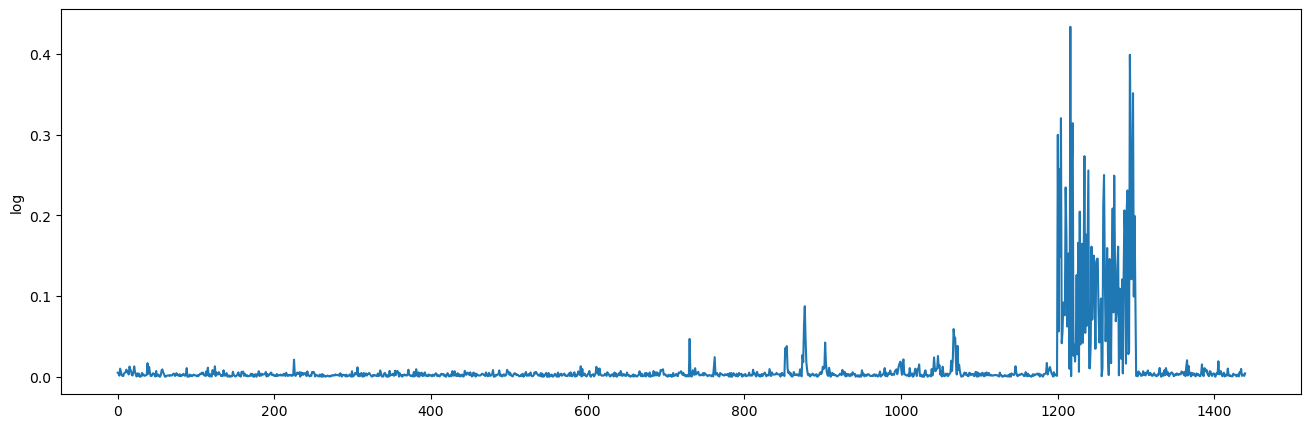

In [172]:
plt.figure(figsize=(16, 5))
idxShow= 0
print(cycSs[idxShow])
plt.ylabel("log")
plt.plot(np.abs(cycResiduals[idxShow,:].T))

(55, 1440)


C:\Users\30678\AppData\Local\Temp\ipykernel_14620\576132088.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


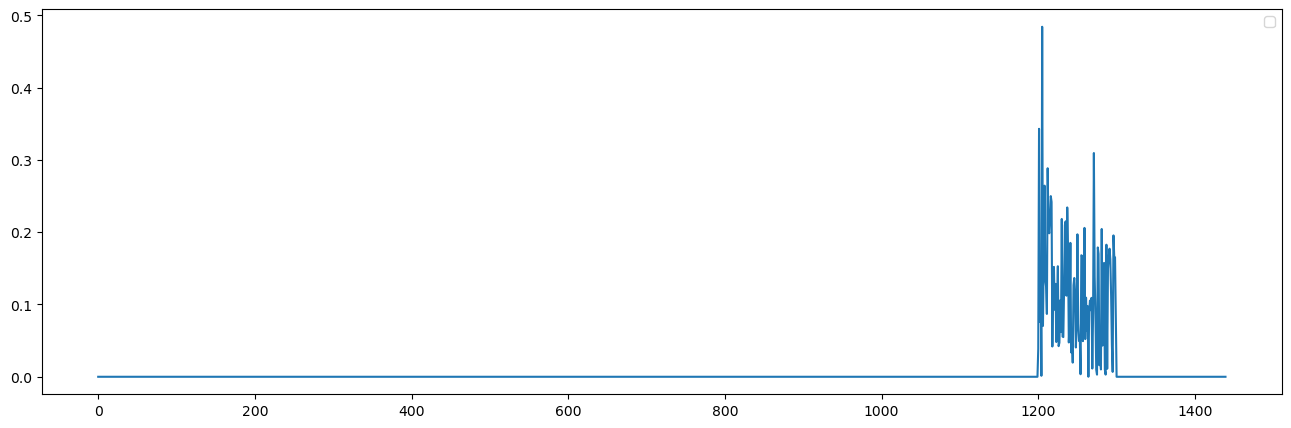

In [173]:
plt.figure(figsize=(16, 5))
print(detect2.shape)
plt.plot(np.abs(detect2[-1, :].T))
plt.legend()

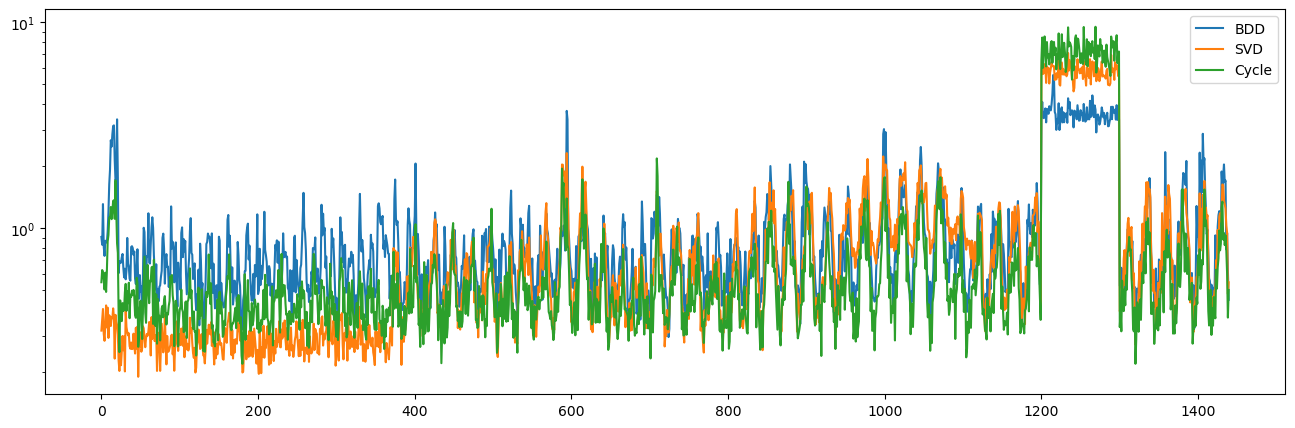

In [174]:
plt.figure(figsize=(16, 5))
plt.plot(normDetect1/np.mean(normDetect1), label= "BDD")
plt.plot(normDetect2/np.mean(normDetect2), label= "SVD")
# plt.plot(LSTMResult/np.mean(LSTMResult), label= "LSTM")
plt.plot(cycResidual/np.mean(cycResidual), label= "Cycle")
plt.legend()
plt.yscale("log")


In [720]:
import json
data_to_save = {
    "BDD": normDetect1.tolist(),
    "SVD": normDetect2.tolist(),
    "LSTM": LSTMResult.tolist(),
    "Cycle": cycResidual.tolist()
}
with open(f'data/results_ac2/IEEE{powerID}.json', 'w') as f:
    json.dump(data_to_save, f, indent=4)